# Dependencies

In [1]:
# Dependencies
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import trimesh

# Adding PATH
# Go up THREE levels (project root directory)
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
# Append the new path to sys.path
if project_root not in sys.path:
    sys.path.append(project_root)
    print("Project root added to sys.path")
else:
    print("Project root already in sys.path")

# Matplotlib settings
# plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = ['Liberation Serif', 'serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

# Helper function
def customize_axes(ax):
    """
    Function to customize axes with specific settings for spines, labels, grid lines, etc.
    
    Args:
        ax: The axes object to customize
    Return:
        None.
    """
    # Set spine visibility and color
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('gray')
        spine.set_linewidth(1.5)

    # Add horizontal and vertical lines at y=0 and x=0
    # ax.axhline(y=0, ls='--', lw=0.5, color='black')
    # ax.axvline(x=0, ls='--', lw=0.5, color='black')

Project root added to sys.path


# Import Data: `mol_meshes`, (e)Centroids, Neighbors

Extract from PLY files: `mol_meshes`.

In [2]:
from utils.generate_mol_meshes import import_meshes

# Import either npz files or ply directory (auto-detect)
mol_meshes = import_meshes(path='npt-HK4_meshes', num_processes=None, context='fork')

Loading 1501 meshes with 8 cores: 100%|██████████| 1501/1501 [00:11<00:00, 132.08it/s]


Extract from CSV files: `e_centroids`, `centroids`, `neighbor_candidates` and `neighbor_pairs`.

In [3]:
def import_csv(path):
    """
    Function to import CSV file and return in appropriate format.
    Handles three types of errors: file not found, incorrect format, and other exceptions.
    
    Parameters
    ----------
        path (str): 
            Path to the CSV file.

    Returns
    -------
        dict[int, arr] or list[tuple]
            The imported data in appropriate format.
    """
    try:
        # Predefined formats
        centroids_format = ['res_id', 'x', 'y', 'z']
        neighbors_format = ['mol_id_1', 'mol_id_2']
        
        # Checks the header of the CSV file
        header = list(pd.read_csv(path, nrows=0))
        
        if header == centroids_format: 
            df_centroids = pd.read_csv(path)
            data = {mol_id: np.array([x, y, z]) for _, mol_id, x, y, z in df_centroids.itertuples()}
            print(f"Successfully imported centroids CSV file: '{path}'.")
            return data

        elif header == neighbors_format:
            df_neighbors = pd.read_csv(path)
            data = [(mol_id_1, mol_id_2) for _, mol_id_1, mol_id_2 in df_neighbors.itertuples()]
            print(f"Successfully imported neighbors CSV file: '{path}'.")
            return data
        
        else:
            raise ValueError(f"Unrecognized CSV format. Found header: {header}")
        
    except ValueError as e:
        print(f"[Error] {e}")
        return None
        
    except FileNotFoundError as e:
        print(e)
        return None
    
    except Exception as e:
        print(f"Error: An unexpected error occurred while importing '{path}'. Details: {e}")
        return None

In [4]:
e_centroids = import_csv('./npt-HK4_e_centroids.csv')
centroids = import_csv('./npt-HK4_centroids.csv')
neighbor_candidates = import_csv('./npt-HK4_neighbor_candidates.csv')
neighbor_pairs = import_csv('./npt-HK4_neighbor_pairs.csv')
fail_1 = import_csv('./npt-HK4_fail_1.csv')  # Should raise error

print('-' * 40)
print(f'{e_centroids=}')
print(f'{centroids=}')
print(f'{neighbor_pairs=}')
print(f'{neighbor_candidates=}')

Successfully imported centroids CSV file: './npt-HK4_e_centroids.csv'.
Successfully imported centroids CSV file: './npt-HK4_centroids.csv'.
Successfully imported neighbors CSV file: './npt-HK4_neighbor_candidates.csv'.
Successfully imported neighbors CSV file: './npt-HK4_neighbor_pairs.csv'.
[Errno 2] No such file or directory: './npt-HK4_fail_1.csv'
----------------------------------------
e_centroids={1: array([ 15.75727273,   3.93227273, 111.68174545]), 2: array([  4.935     ,   7.26454545, 108.39227273]), 3: array([  7.66909091, 108.07818182,   8.69727273]), 4: array([ 1.52731818, 10.37727273,  1.91959091]), 5: array([55.41954545,  1.17957273, 58.02727273]), 6: array([92.80727273, 66.47681818,  7.53409091]), 7: array([ 68.19590909, 100.06045455,  71.07681818]), 8: array([25.97636364, 68.23909091, 69.13727273]), 9: array([79.10227273, 92.49590909, 84.83954545]), 10: array([17.76818182, 88.35590909, 23.54772727]), 11: array([78.41590909, 97.155     , 21.39      ]), 12: array([73.1563

# Data Analysis

## Obtain Symmetric Data

Made `neighbor_candidates` and `neighbor_pairs` symmetric to plot histogram and blocking visualisation.

Symmetric meaning exist _'duplicate edges'_ (e.g. `neighbor_pairs = {1:[5,6], ..., 5:[1,6], 6:[1,5,10], ...}`).

In [5]:
from collections import defaultdict

def map_symmetric_neighbors(neighbor_candidates, centroids, fill_no_neighbor_mols=False):
    """
    Function to create a symmetric mapping of neighbor candidates.
    
    Parameters
    ----------
        neighbor_candidates: list[tuple[int, int]]
            List of tuples representing neighbor pairs, e.g. [(mol_id_1, mol_id_2),...].
        centroids: dict[int, arr]
            Dictionary mapping molecule IDs to their centroids.
        fill_no_neighbor_mols: bool, optional
            If True, ensures that molecules with no neighbors are included in the dictionary.
    Returns
    -------
        neighbor_candidates_symmetric: dict[int, list[int]]
            Dictionary mapping each molecule ID to a list of its neighbors.
    """
    neighbor_map = defaultdict(list)
    for mol_id_1, mol_id_2 in neighbor_candidates:
        neighbor_map[mol_id_1].append(mol_id_2) # Pass 1
        neighbor_map[mol_id_2].append(mol_id_1) # Pass 2
    
    # Molecules with no neighbors are included
    if fill_no_neighbor_mols is True:
        superset = set(centroids.keys())
        subset = set(neighbor_map.keys())
        no_neighbor_mols = superset - subset
        
        for mol_id in no_neighbor_mols:
            neighbor_map[mol_id] = []
        
        
    neighbor_candidates_symmetric = dict(neighbor_map)
    return neighbor_candidates_symmetric

# Symmetric mapping for neighbor candidates
snc = map_symmetric_neighbors(neighbor_candidates, centroids, fill_no_neighbor_mols=False)
print(f'Symmetric neighbor candidates: {snc}')
# Symmetric mapping for neighbor pairs
snp = map_symmetric_neighbors(neighbor_pairs, centroids, fill_no_neighbor_mols=True)
print(f'Symmetric_neighbor_pairs: {snp}')

Symmetric neighbor candidates: {1: [2, 18, 164, 244, 847, 943, 1088, 1283, 1308, 1370], 2: [1, 4, 18, 127, 244, 274, 610, 704, 780, 850], 18: [1, 2, 164, 244, 282, 610, 850, 943, 1176, 1249], 164: [1, 18, 244, 282, 610, 611, 902, 1249, 1283, 1427], 244: [1, 2, 18, 164, 610, 611, 943, 1176, 1249, 1283], 847: [1, 3, 210, 359, 979, 1308, 1349, 1380, 1394], 943: [1, 3, 18, 192, 244, 282, 747, 850, 1088], 1088: [1, 192, 747, 943, 1008, 1152, 1283, 1308, 1349], 1283: [1, 164, 244, 519, 567, 611, 782, 902, 1088, 1370, 1438], 1308: [1, 3, 192, 847, 1088, 1152, 1349, 1380, 1394], 1370: [1, 471, 519, 567, 611, 782, 902, 1283, 1438], 4: [2, 127, 226, 274, 704, 780, 878, 1031, 1206, 1330], 127: [2, 4, 226, 274, 704, 718, 780, 850, 1181, 1245], 274: [2, 4, 127, 226, 660, 780, 878, 1031, 1223, 1343], 610: [2, 18, 164, 244, 282, 902, 1046, 1176, 1249, 1427, 1487], 704: [2, 3, 4, 127, 780, 850, 1014, 1181, 1245, 1461], 780: [2, 4, 127, 226, 274, 660, 704, 1031, 1181, 1245], 850: [2, 3, 18, 127, 704, 9

In [ ]:
# Old blocking
neighbor_candidates_2 = import_csv('./old_neighbor_candidates.csv')
snc2 = map_symmetric_neighbors(neighbor_candidates_2, centroids, fill_no_neighbor_mols=False)

neighbor_pairs_2 = import_csv('./old_neighbor_pairs.csv')
snp2 = map_symmetric_neighbors(neighbor_pairs_2, centroids, fill_no_neighbor_mols=True)

## Histogram Checking

From the result below:
- Skewness is
- Kurtosis is

In [21]:
from collections import Counter
import scipy.stats as stats

# Number of bonds per molecule
data = [len(neighbors) for neighbors in snp.values()]
print(f'Data: {data}')

# Descriptive statistics
print(f"Dataset size: {len(data)}")
print(f"Mean: {np.mean(data):.3f}")
print(f"Median: {np.median(data):.3f}")
print(f"Standard deviation: {np.std(data):.3f}")
print(f"Variance: {np.var(data):.3f}")
print(f"Range: {np.ptp(data)}")
print(f"Minimum: {np.min(data)}")
print(f"Maximum: {np.max(data)}")
print(f"Q1 (25th percentile): {np.percentile(data, 25):.3f}")
print(f"Q3 (75th percentile): {np.percentile(data, 75):.3f}")
print(f"IQR: {stats.iqr(data):.3f}")
print(f"Skewness: {stats.skew(data):.3f}")
print(f"Kurtosis: {stats.kurtosis(data):.3f}")

# Quick data description
# display(stats.describe(data))

Data: [10, 8, 7, 7, 10, 8, 7, 9, 11, 8, 9, 7, 10, 9, 10, 8, 9, 6, 8, 9, 10, 10, 9, 6, 7, 11, 10, 9, 12, 9, 10, 8, 9, 8, 8, 11, 10, 10, 9, 9, 4, 9, 8, 8, 9, 8, 12, 11, 7, 8, 10, 10, 10, 7, 7, 10, 9, 9, 8, 10, 12, 8, 9, 12, 8, 10, 10, 8, 8, 7, 10, 12, 9, 9, 10, 12, 9, 8, 10, 8, 11, 9, 8, 9, 11, 7, 8, 10, 10, 9, 11, 10, 8, 8, 11, 10, 11, 9, 8, 10, 8, 10, 9, 13, 10, 10, 9, 11, 11, 14, 9, 12, 10, 8, 10, 8, 10, 10, 7, 7, 9, 9, 10, 6, 9, 10, 9, 9, 8, 8, 9, 6, 6, 10, 11, 10, 9, 9, 11, 9, 9, 10, 11, 11, 9, 9, 9, 9, 7, 10, 7, 9, 9, 10, 11, 9, 10, 9, 8, 10, 8, 11, 9, 8, 11, 12, 9, 9, 10, 9, 8, 9, 10, 10, 10, 9, 10, 7, 9, 10, 11, 9, 11, 7, 9, 7, 8, 7, 9, 9, 8, 9, 8, 10, 9, 9, 9, 9, 6, 8, 10, 12, 12, 10, 10, 9, 8, 9, 10, 7, 9, 8, 8, 7, 11, 8, 9, 10, 11, 11, 8, 8, 7, 10, 8, 11, 6, 12, 5, 9, 6, 9, 6, 9, 9, 9, 9, 5, 8, 10, 9, 9, 6, 7, 12, 9, 10, 11, 9, 8, 7, 8, 11, 11, 9, 10, 9, 10, 10, 10, 10, 7, 9, 9, 12, 9, 9, 7, 8, 9, 9, 9, 10, 10, 10, 10, 8, 13, 8, 9, 11, 10, 10, 10, 11, 9, 9, 8, 9, 11, 10, 10, 8

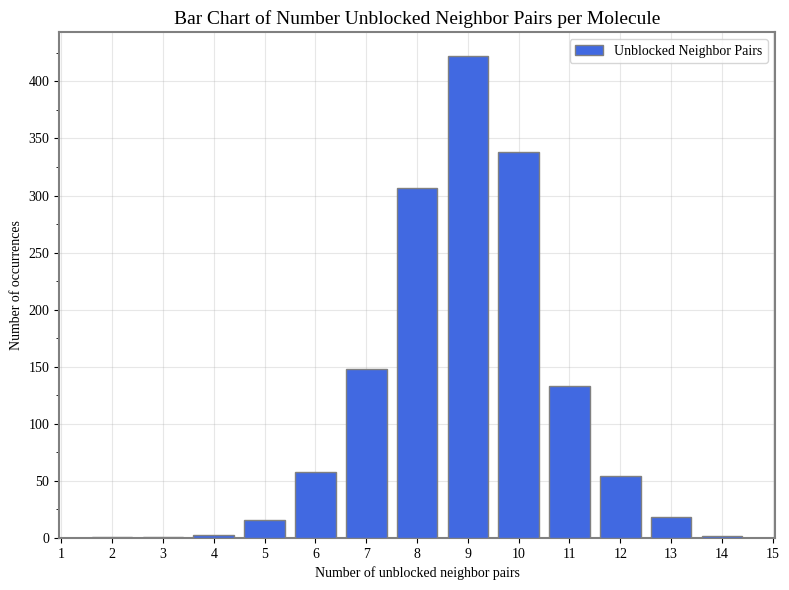

In [22]:
# Histogram data
counts = Counter(data)
x_values = sorted(counts.keys())
y_counts = [counts[val] for val in x_values]
# print(f'{counts=}')
# print(f'{x_values=}')
# print(f'{y_counts=}')

# Create figure and define subplots
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot graph
ax.bar(x_values, y_counts, width=0.8, label="Unblocked Neighbor Pairs", align='center', color='royalblue', edgecolor='gray', zorder=3)
ax.set_title("Bar Chart of Number Unblocked Neighbor Pairs per Molecule", fontsize=14)

# Customize the appearance of the axes
customize_axes(ax)
ax.grid(True, alpha=0.3, zorder=0)
ax.set_xlabel('Number of unblocked neighbor pairs')
ax.set_ylabel('Number of occurrences')

# ax.set_xlim(-1, 11)
# ax.set_ylim(0, 350)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(0))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(25))

# Show legend
ax.legend(loc='best', frameon=True, facecolor='white')

# Show graph
plt.tight_layout()
plt.show()
# plt.savefig('template_plot.svg', bbox_inches='tight')

## Visual Checking

Use `neighbor_candidates` and `neighbor_pairs` to visualise blocking.

In [7]:
import time
import ast
from matplotlib import colors as mcolors
import numpy as np

def get_distinct_colors(n, alpha=200, method='hsv'):
    """
    Return a list of n RGBA colors in 0-255 int format.
    method: 'hsv' (even hue spacing) or 'matplotlib_tab' (uses tab20).
    alpha: 0-255
    """
    if n <= 0:
        return []
    if method == 'matplotlib_tab':
        # tab20 has up to 20 distinct categorical colors
        cmap = plt.get_cmap('tab20')
        colors = [cmap(i) for i in range(n)]
        # cmap returns RGBA floats 0-1 -> convert
        colors = [(int(r*255), int(g*255), int(b*255), int(a*255)) for (r,g,b,a) in colors]
        return colors
    # default: evenly spaced HSV hues (good for 1..11)
    hues = np.linspace(0, 1, n, endpoint=False)
    sats = 0.65   # saturation
    vals = 0.90   # value (brightness)
    colors = []
    for h in hues:
        rgb = mcolors.hsv_to_rgb((h, sats, vals))  # returns 3 floats 0..1
        colors.append((int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255), int(alpha)))
    return colors

def get_user_input_unpaired(exclusive_ids):
    """Handles the user prompt for selecting unpaired neighbors to view."""
    
    print("Select the non-paired neighbors to view. Use the following format:")
    print("  - For specific molecules: '[101, 104, 403]'")
    print("  - For all neighbors: 'all'")
    print(f"  - For no neighbors: ''\n{"-" * 40}")
    time.sleep(1)

    view_ids = input("View: ")
    
    # Process user input
    try:
        view_input = view_ids.strip().lower()
        
        if view_input == 'all':
            user_select_ids = exclusive_ids
            return user_select_ids
        
        elif view_input == '': 
            user_select_ids = []
            return user_select_ids
            
        else:
            # Safely evaluate list input
            user_select_ids = ast.literal_eval(view_ids)
            
            # Check if user input is a list of integers
            if not isinstance(user_select_ids, list) or not all(isinstance(int(x), int) for x in user_select_ids):
                 raise ValueError("Input is not a valid list of integers.")
             
            # Final validation check
            if not set(user_select_ids).issubset(set(exclusive_ids)):
                print(f"Selected molecule ID not in neighbor list. Please try again.")
                return None
             
            return user_select_ids
    
    except Exception as e:
        print(f"Invalid input format. Please use the specified format or check IDs.")
        # print(f"Error details: {e}") # Optional: for debugging
        return None

In [ ]:


view_molecule(100, 'npt-HK4_e_centroids.csv', mol_meshes, )

In [8]:
def view_molecule(mol_id, e_centroids, mol_meshes, 
                  symmetric_neighbor_candidates, 
                  symmetric_neighbor_pairs,
                  view_unpaired_mols=None,
                  distinct_color=False):
    """
    Function to visualize a molecule with its mesh, e-centroid, centroid, and neighbors.
    
    Parameters
    ----------
        mol_id: int
            The ID of the molecule to visualize.
        e_centroids: dict[int, np.ndarray]
            Dictionary mapping molecule IDs to their e-centroid coordinates.
        mol_meshes: dict[int, trimesh.Trimesh]
            Dictionary mapping molecule IDs to their mesh objects.
        neighbor_candidates: dict[int, list[int]]
            Dictionary mapping each molecule ID to a list of its neighbor candidates.
        neighbor_pairs: dict[int, list[int]]
            Dictionary mapping each molecule ID to a list of its confirmed neighbors.
        view_unpaired_mols: boolean, int, list[int], optional
            List of molecule IDs to specifically view. If True, view all unpaired neighbors.
            If False, view no unpaired neighbors. If None, prompt user for input.
        distinct_color: boolean, optional
            If True, use a monotone color scheme for the meshes for higher contrast.
    Returns
    -------
        None. Displays a 3D plot of the molecule and its neighbors.
    """
    # Parameters
    snc_ids = symmetric_neighbor_candidates[mol_id]
    snp_ids = symmetric_neighbor_pairs[mol_id]
    exclusive_ids = sorted(list(set(snc_ids).difference(set(snp_ids))))
    
    # Show to user paired neighbors
    print(f'Neighbor pairs for molecule {mol_id}: {snp_ids}')
    print(f'Non-paired neighbors are: {exclusive_ids}\n{"-"*40}')
    time.sleep(1)
    
    # -----------------------------
    # User WANT TO SEE ALL (True), show all unpaired neighbors 
    if view_unpaired_mols is True: user_select_ids = exclusive_ids

    # User DOESN'T WANT TO SEE ANY (False), show no unpaired neighbors
    elif view_unpaired_mols is False: user_select_ids = []
    
    # User WANT TO A FEW, show the number of unpaired neighbors specified by user
    elif isinstance(view_unpaired_mols, int): 
        if view_unpaired_mols < 0:
            print("Please enter a non-negative integer for the number of unpaired neighbors to view."); return None
        elif view_unpaired_mols > len(exclusive_ids):
            print(f"Only {len(exclusive_ids)} unpaired neighbors available. Showing all of them.")
            user_select_ids = exclusive_ids
        else:
            user_select_ids = exclusive_ids[:view_unpaired_mols]
    
        
    # User DOES NOT SPECIFY (None), prompt user which unpaired neighbors to view
    elif view_unpaired_mols is None: user_select_ids = get_user_input_unpaired(exclusive_ids)
    
    # User DOES SPECIFY (list), use their selection of unpaired neighbors
    else:
        user_select_ids = view_unpaired_mols
        # Check if user input is valid
        if not set(user_select_ids).issubset(set(exclusive_ids)): 
            print(f"Selected molecule ID not in neighbor list. Please try again."); return None
    # -----------------------------

    # Verified successful input
    print(f"You have selected: {user_select_ids}"); time.sleep(1) 
    
    # Overall molecule meshes to show
    meshes_to_show_ids = sorted([mol_id] + snp_ids + user_select_ids)
    meshes_to_show = [mol_meshes[ids] for ids in meshes_to_show_ids]
    print(f'{'-'*40}\nYou are now viewing molecules {meshes_to_show_ids}')

    # Line mesh for unblocked neighbors
    meshes_lines = []
    target_coord = e_centroids[mol_id]
    for ids in snp_ids:
        neighbor_coord = e_centroids[ids]
        segment = [target_coord, neighbor_coord]
        cyl = trimesh.creation.cylinder(radius=0.05, segment=segment, sections=24)
        cyl.visual.face_colors = [255, 255, 0, 100] # Yellow color
        meshes_lines.append(cyl)
        
    # Palette color scheme for higher contrast
    if distinct_color == True:
        palette = get_distinct_colors(len(meshes_to_show), alpha=200, method='hsv')
        for mesh, color in zip(meshes_to_show, palette):
            num_vertices = len(mesh.vertices)
            num_faces = len(mesh.faces)
            mesh.visual.face_colors = np.tile(color, (num_vertices, 1))
            mesh.visual.face_colors = np.tile(color, (num_faces, 1))
    
    meshes = trimesh.util.concatenate(meshes_to_show  + meshes_lines)
    scene = trimesh.Scene(meshes)
    
    return scene.show()

In [32]:
# PROBLEM: Molecule does not consider itself when blocking neighbors
view_molecule(mol_id=100, e_centroids=centroids, mol_meshes=mol_meshes, 
                             symmetric_neighbor_candidates=snc2, symmetric_neighbor_pairs=snp2, 
                             view_unpaired_mols=False, distinct_color=True)

Neighbor pairs for molecule 100: [552, 838, 1414]
Non-paired neighbors are: [113, 237, 741, 1034, 1048, 1073, 1081]
----------------------------------------
You have selected: []
----------------------------------------
You are now viewing molecules [100, 552, 838, 1414]
